                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(3, 2, 1)   Log Likelihood                -298.008
Date:                Wed, 04 Mar 2026   AIC                            606.015
Time:                        11:00:49   BIC                            622.456
Sample:                             0   HQIC                           612.670
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7468      0.084     -8.933      0.000      -0.911      -0.583
ar.L2         -0.4784      0.101     -4.734      0.000      -0.676      -0.280
ar.L3         -0.1753      0.081     -2.155      0.0

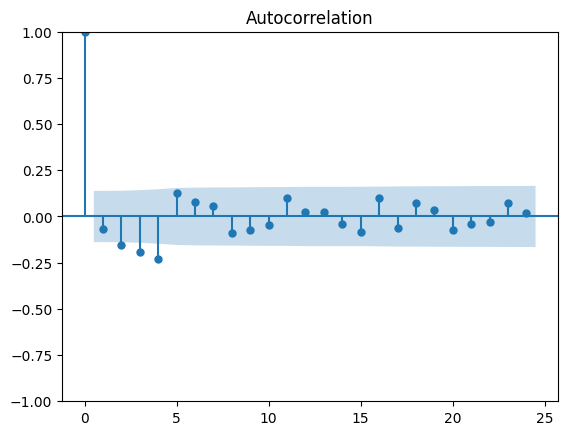

In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# ------------------------------
# Generate sample time series data
# ------------------------------
np.random.seed(42)
data = np.random.normal(0, 1, 200)
series = pd.Series(data)

# ------------------------------
# ARIMA order parameter explanation:
#
# order = (p, d, q)
#
# p → Number of past values (AR terms)
# d → Number of differencing steps (to make data stationary)
# q → Number of past error terms (MA terms)
#
# Example below:
# order = (3, 2, 1)
#
# p = 3 → Model uses 3 past observations (Y_t-1, Y_t-2, Y_t-3)
# d = 2 → Data is differenced 2 times to make it stationary
# q = 1 → Model uses 1 past error term (ε_t-1)
# ------------------------------

# Fit ARIMA(3,2,1)
model = ARIMA(series, order=(3, 2, 1))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

# Print AIC value
print("\nAIC:", model_fit.aic)

# Get residuals (Actual - Predicted)
residuals = model_fit.resid

# Show first few residuals
print("\nFirst 5 Residuals:")
print(residuals.head())

# plot the residuals
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals)
plt.show()